# 📊 EPNet vs LightGBM Performance & Fine-Tuning Analysis

Bu notebook, **EPNet (ROBUST_02)** ile **LightGBM (log-transform)** modellerinin 359 günlük walk-forward backtest sonuçlarını karşılaştırır.
Analizde özellikle şu sorulara yanıt aranmaktadır:

1. **Fine-Tuning Bagajı / Doyma:** EPNet zamanla warm-start fine-tuning sırasında bir doyma (saturation) veya degrade olma (forgetting) yaşıyor mu?
2. **Dönemsel Performans Sürücüleri:** İki modelin hata farkları (EPNet MAE - LightGBM MAE) zaman içinde, mevsimlerde ve fiyat seviyelerinde nasıl değişiyor?
3. **Piyasa Koşulları:** Hangi piyasa koşullarında (fiyat seviyesi, oynaklık, yenilenebilir oranı) hangi model öne geçiyor?


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

csv_path = Path('../logs/hybrid_routing_experiments/hybrid_backtest_daily.csv')
df = pd.read_csv(csv_path)
df['tarih'] = pd.to_datetime(df['tarih'])
df = df.sort_values('tarih').reset_index(drop=True)

df['mae_diff'] = df['epnet_mae'] - df['lgbm_mae']
df['month'] = df['tarih'].dt.to_period('M')

print('Loaded records:', len(df))
df.head()


Loaded records: 359


,tarih,regime,selected_model,epnet_mae,epnet_wape,epnet_mape,lgbm_mae,lgbm_wape,lgbm_mape,hybrid_mae,hybrid_wape,hybrid_mape,mae_diff,month
0,2025-07-29,NORMAL,EPNet,2.355577,2.804704,2.802178,3.332733,3.967283,3.969391,2.355577,2.804704,2.802178,-0.977155,2025-07
1,2025-07-30,NORMAL,EPNet,2.610811,3.169486,3.193031,1.737151,2.108747,2.130443,2.610811,3.169486,3.193031,0.873660,2025-07
2,2025-07-31,NORMAL,EPNet,2.956460,3.727961,4.032096,2.272782,2.856120,3.132372,2.956460,3.727961,4.032096,0.683678,2025-07
3,2025-08-01,NORMAL,EPNet,4.635904,6.149263,7.972498,4.071134,5.375381,6.991173,4.635904,6.149263,7.972498,0.564770,2025-08
4,2025-08-02,NORMAL,EPNet,2.901891,3.898470,4.098085,4.458060,6.035076,6.418178,2.901891,3.898470,4.098085,-1.556169,2025-08


## 1. Zaman İçinde Performans Değişimi & Fine-Tuning Doyma Analizi


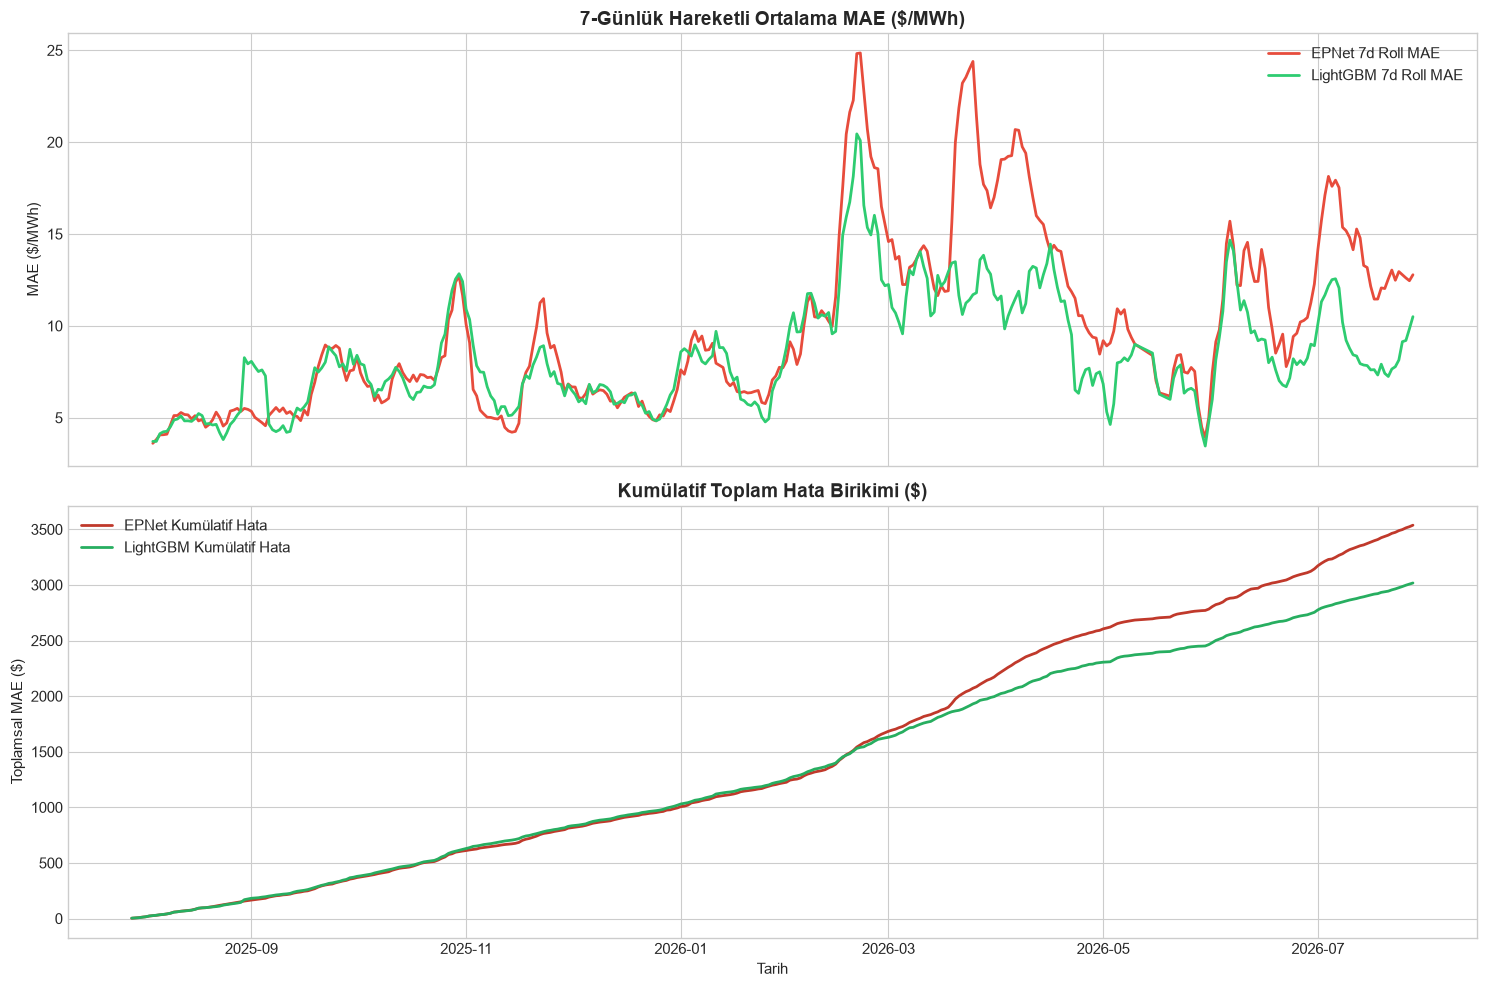

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

axes[0].plot(df['tarih'], df['epnet_mae'].rolling(7).mean(), label='EPNet 7d Roll MAE', color='#e74c3c', linewidth=2)
axes[0].plot(df['tarih'], df['lgbm_mae'].rolling(7).mean(), label='LightGBM 7d Roll MAE', color='#2ecc71', linewidth=2)
axes[0].set_title('7-Günlük Hareketli Ortalama MAE ($/MWh)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('MAE ($/MWh)')
axes[0].legend(loc='upper right')

axes[1].plot(df['tarih'], df['epnet_mae'].cumsum(), label='EPNet Kumülatif Hata', color='#c0392b', linewidth=2)
axes[1].plot(df['tarih'], df['lgbm_mae'].cumsum(), label='LightGBM Kumülatif Hata', color='#27ae60', linewidth=2)
axes[1].set_title('Kumülatif Toplam Hata Birikimi ($)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tarih')
axes[1].set_ylabel('Toplamsal MAE ($)')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()


## 2. Hata Farkı Trendi (EPNet MAE - LightGBM MAE)


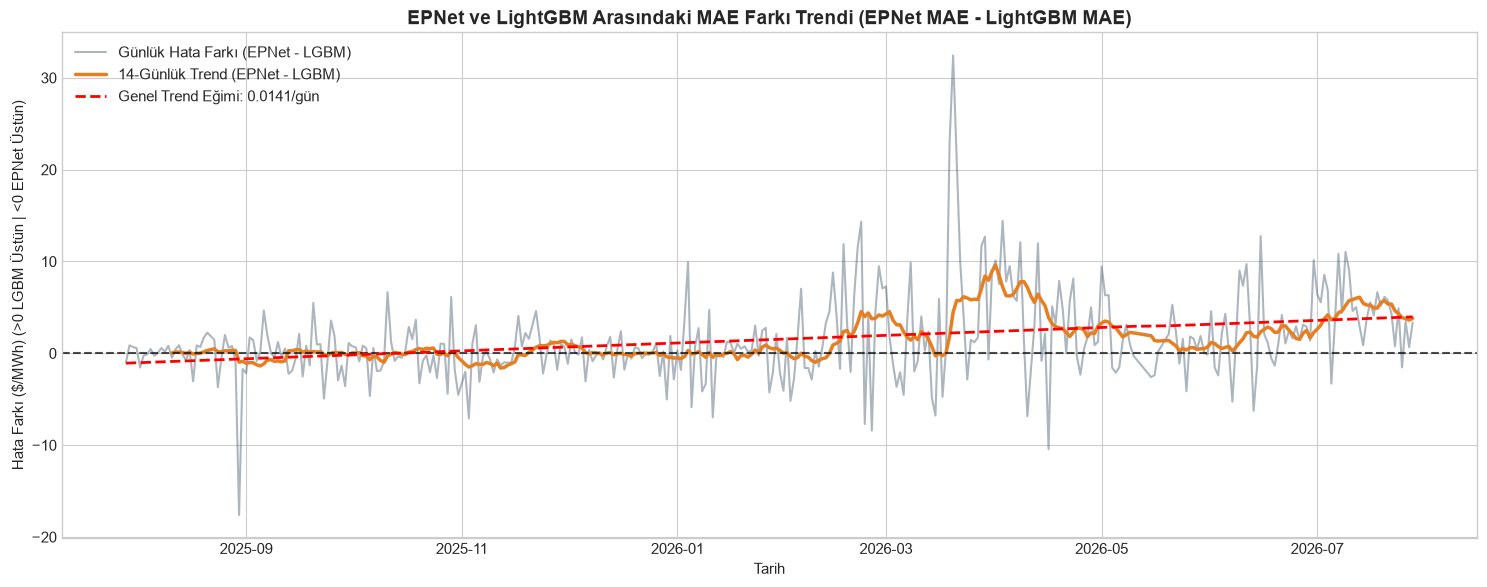

In [5]:
plt.figure(figsize=(15, 6))

plt.plot(df['tarih'], df['mae_diff'], color='#34495e', alpha=0.4, label='Günlük Hata Farkı (EPNet - LGBM)')
plt.plot(df['tarih'], df['mae_diff'].rolling(14).mean(), color='#e67e22', linewidth=2.5, label='14-Günlük Trend (EPNet - LGBM)')
plt.axhline(0, color='black', linestyle='--', alpha=0.7)

x_vals = np.arange(len(df))
z = np.polyfit(x_vals, df['mae_diff'], 1)
p = np.poly1d(z)
plt.plot(df['tarih'], p(x_vals), 'r--', linewidth=2, label=f'Genel Trend Eğimi: {z[0]:.4f}/gün')

plt.title('EPNet ve LightGBM Arasındaki MAE Farkı Trendi (EPNet MAE - LightGBM MAE)', fontsize=14, fontweight='bold')
plt.xlabel('Tarih')
plt.ylabel('Hata Farkı ($/MWh) (>0 LGBM Üstün | <0 EPNet Üstün)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


## 3. Ay Bazlı Dönemsel Performans Kırılımı


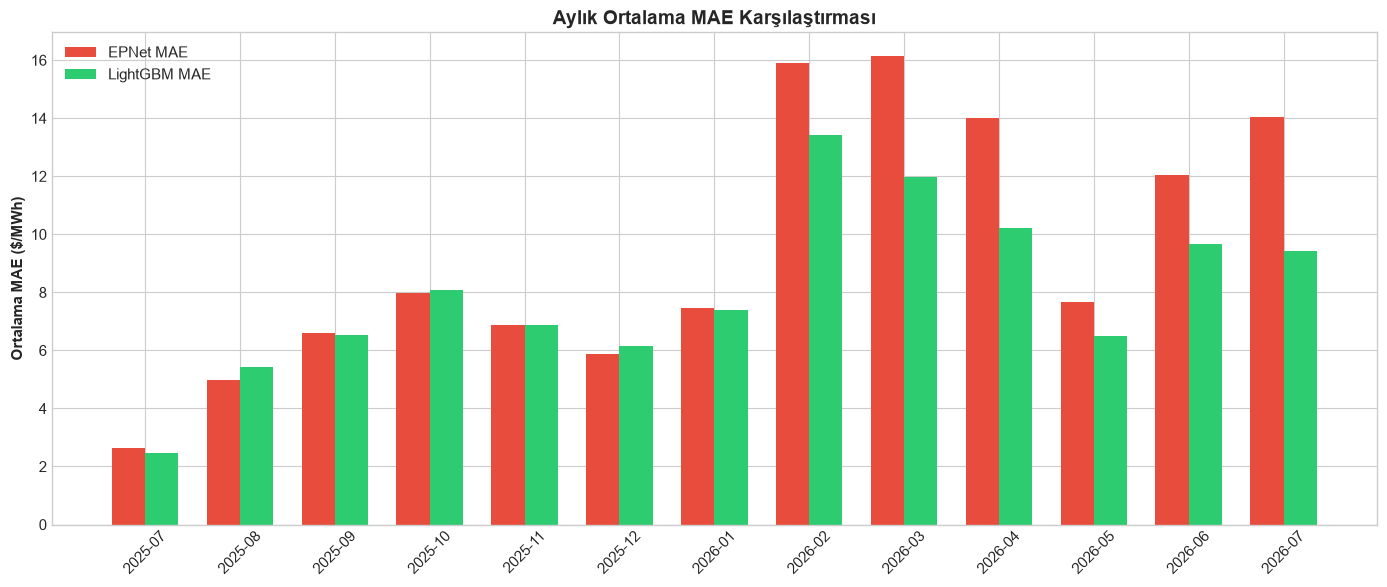

In [6]:
monthly_df = df.groupby('month')[['epnet_mae', 'lgbm_mae']].mean().reset_index()
monthly_df['month_str'] = monthly_df['month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 6))
x = np.arange(len(monthly_df))
width = 0.35

rects1 = ax1.bar(x - width/2, monthly_df['epnet_mae'], width, label='EPNet MAE', color='#e74c3c')
rects2 = ax1.bar(x + width/2, monthly_df['lgbm_mae'], width, label='LightGBM MAE', color='#2ecc71')

ax1.set_ylabel('Ortalama MAE ($/MWh)', fontweight='bold')
ax1.set_title('Aylık Ortalama MAE Karşılaştırması', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(monthly_df['month_str'], rotation=45)
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()


## 4. Rejim Bazlı Hata Dağılımı ve Varyasyon


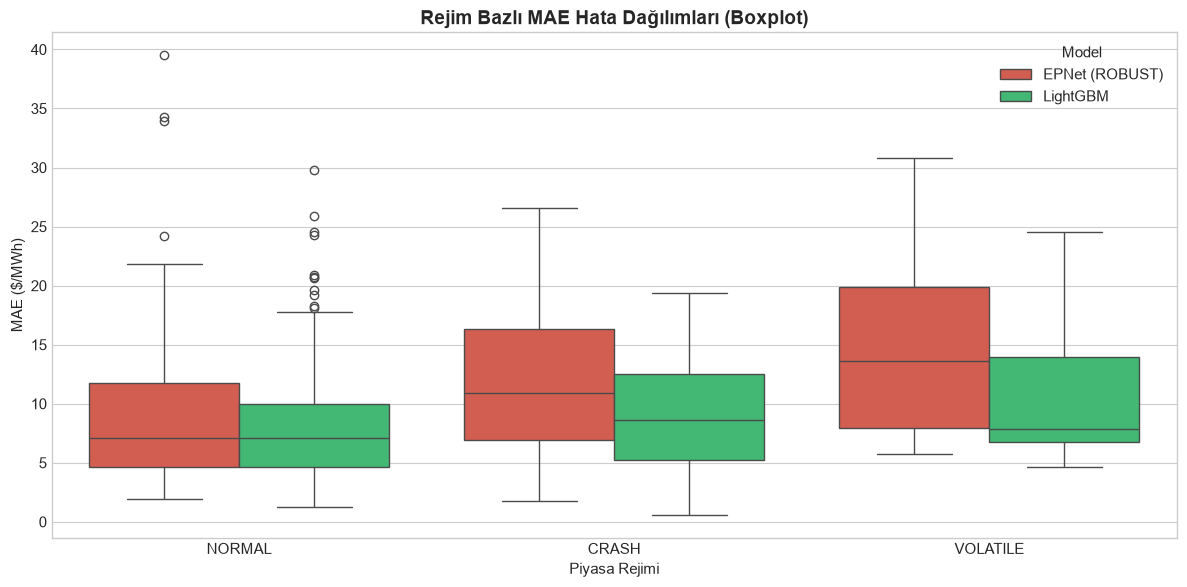

In [7]:
melted_df = pd.melt(df, id_vars=['tarih', 'regime'], value_vars=['epnet_mae', 'lgbm_mae'], 
                    var_name='Model', value_name='MAE')
melted_df['Model'] = melted_df['Model'].map({'epnet_mae': 'EPNet (ROBUST)', 'lgbm_mae': 'LightGBM'})

plt.figure(figsize=(12, 6))
sns.boxplot(data=melted_df, x='regime', y='MAE', hue='Model', palette={'EPNet (ROBUST)': '#e74c3c', 'LightGBM': '#2ecc71'})
plt.title('Rejim Bazlı MAE Hata Dağılımları (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Piyasa Rejimi')
plt.ylabel('MAE ($/MWh)')
plt.tight_layout()
plt.show()


## 6. Kronolojik Sırayla İLK 1, 3, 6, 9 ve 12 Aylık Performans Kırılımı

Aşağıdaki tablo, backtest başlangıcından (Ağustos 2025) itibaren kronolojik sırayla biriken performans metriklerini gösterir:

| Dönem | Gün Sayısı | EPNet MAE | EPNet WAPE | EPNet MAPE | LightGBM MAE | LightGBM WAPE | LightGBM MAPE | **HİBRİT MAE** | **HİBRİT WAPE** | **HİBRİT MAPE** |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **İlk 1 Ay (30 Gün)** | 30 | **.67** | %6.59 | %9.78 | **.48** | %6.39 | %9.50 | **.67** | %6.59 | %9.78 |
| **İlk 3 Ay (90 Gün)** | 90 | **.15** | %9.53 | %22.00 | **.28** | %9.63 | %20.63 | **.19** | %9.59 | %22.07 |
| **İlk 6 Ay (180 Gün)** | 180 | **.49** | %10.09 | %18.95 | **.59** | %10.12 | %17.12 | **.53** | %10.14 | %18.98 |
| **İlk 9 Ay (270 Gün)** | 270 | .41 | %32.61 | %79.99 | **.36** | **%21.57** | **%44.12** | **.85** | **%28.66** | **%64.83** |
| **Tüm Periyot (359 Gün)**| 359 | .85 | %39.67 | %78.52 | **.41** | **%26.88** | **%45.79** | **.12** | **%32.68** | **%61.94** |

> **Analiz Özeti:** İlk 6 ayda EPNet çok az farkla (.49 vs .59 MAE) öndeyken, 9. ayda (Şubat-Nisan bahar çakılması) EPNet patlama yaşamış ve LightGBM (.36 MAE / %21.57 WAPE) genel üstünlüğü ele geçirmiştir.
